In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df=pd.read_csv("netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
# Renaming the listed in column to genre
df.rename(columns={'listed_in':'genre'},inplace=True)
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description'],
      dtype='object')

In [ ]:
# Dropping the show_id column as it may be of no use in the analysis
df.drop(columns='show_id',inplace=True)

In [ ]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# check the missing values
df.isnull().sum()

,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3
genre,0


In [ ]:
#here we can see clearly here some count are so big and some are so small
#which is available in less quantity we can drop them

In [ ]:
#as we have studied
# if we write df.dropna()---- all the rows having missing values got deleted
# if we write df.dropna(axis=1) the columns having missing value got deleted

# if we want to delete missing value from specific column
# df.dropna(subset=["Column_name"],axis=1,inplace=True)

In [ ]:
df.shape

(8807, 11)

In [ ]:
# Dropping the rows which have null values in data_added column as there are only 10 values
df.dropna(subset=['date_added'],inplace=True)
df['date_added'].isna().sum()

np.int64(0)

In [ ]:
# dropping the rows which have null values in rating column as there are only 4 values
df.dropna(subset=['rating'],inplace=True)
df['rating'].isna().sum()

np.int64(0)

In [ ]:
# dropping the rows which have null values in duration column as there are only 3 values
df.dropna(subset=['duration'],inplace=True)
df['rating'].isna().sum()

np.int64(0)

In [ ]:
# converting the data added column from object to datetime format
# when there is some mismatch in our date format then that value is replaced by null that is coerce
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
df['date_added'].isnull().sum()

np.int64(88)

In [ ]:
df.dropna(subset=['date_added'],inplace=True)
df['date_added'].isna().sum()

np.int64(0)

In [ ]:
#Adding day,month,year,month_name,day_nameas seperate columns to the dataframe
df['day']=df['date_added'].dt.day
df['month']=df['date_added'].dt.month
df['year']=df['date_added'].dt.year
df['month_name']=df['date_added'].dt.month_name()
df['weekday']=df['date_added'].dt.day_name()
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [ ]:
df["duration"].unique()

array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min', '3 Seasons', '110 min', '105 min',
       '96 min', '124 min', '116 min', '98 min', '23 min', '115 min',
       '122 min', '99 min', '88 min', '100 min', '6 Seasons', '102 min',
       '93 min', '95 min', '85 min', '83 min', '113 min', '13 min',
       '182 min', '48 min', '145 min', '87 min', '92 min', '80 min',
       '117 min', '128 min', '119 min', '143 min', '114 min', '118 min',
       '108 min', '63 min', '121 min', '142 min', '154 min', '120 min',
       '82 min', '109 min', '101 min', '86 min', '229 min', '76 min',
       '89 min', '156 min', '112 min', '107 min', '129 min', '135 min',
       '136 min', '165 min', '150 min', '133 min', '70 min', '84 min',
       '140 min', '78 min', '7 Seasons', '64 min', '59 min', '139 min',
    

In [ ]:
s1='179 min'
int(s1.split()[0])

179

In [ ]:
s1='12 Seasons'
int(s1.split()[0])

12

In [ ]:
df["duration"]=df["duration"].apply(lambda x:int(x.split()[0]))

In [ ]:
df["duration"].unique()

array([ 90,   2,   1,  91, 125,   9, 104, 127,   4,  67,  94,   5, 161,
        61, 166, 147, 103,  97, 106, 111,   3, 110, 105,  96, 124, 116,
        98,  23, 115, 122,  99,  88, 100,   6, 102,  93,  95,  85,  83,
       113,  13, 182,  48, 145,  87,  92,  80, 117, 128, 119, 143, 114,
       118, 108,  63, 121, 142, 154, 120,  82, 109, 101,  86, 229,  76,
        89, 156, 112, 107, 129, 135, 136, 165, 150, 133,  70,  84, 140,
        78,   7,  64,  59, 139,  69, 148, 189, 141, 130, 138,  81, 132,
        10, 123,  65,  68,  66,  62,  74, 131,  39,  46,  38,   8,  17,
       126, 155, 159, 137,  12, 273,  36,  34,  77,  60,  49,  58,  72,
       204, 212,  25,  73,  29,  47,  32,  35,  71, 149,  33,  15,  54,
       224, 162,  37,  75,  79,  55, 158, 164, 173, 181, 185,  21,  24,
        51, 151,  42,  22, 134, 177,  52,  14,  53,  57,  28,  50,  26,
        45, 171,  27,  44, 146,  20, 157, 203,  41,  30, 194, 233, 237,
       230, 195, 253, 152, 190, 160, 208, 180, 144, 174, 170, 19

In [ ]:
#checking for unique values of rating and categorising them for better understanding
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [ ]:
#Netflix has officially categorised these into 3 main categories
df['rating']=df['rating'].replace(['TV-Y','TV-Y7','G','TV-G','PG','TV-PG','TV-Y7-FV'],'Kids')
df['rating']=df['rating'].replace(['PG-13','TV-14'],'Teens')
df['rating']=df['rating'].replace(['R','TV-MA','NC-17'],'Adults')
df['rating']=df['rating'].replace(['NR','UR'],np.nan)
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,Adults,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [ ]:
df['rating'].unique()

array(['Teens', 'Adults', 'Kids', nan], dtype=object)

In [ ]:
df.dropna(subset=['rating'],inplace=True)
df['rating'].isna().sum()

np.int64(0)

In [ ]:
#
df['rating'].isna().sum()

np.int64(0)

In [ ]:
df[(df['director'].isna()) & (df['country'].isna()) & (df['cast'].isna())].shape[0]

96

In [ ]:
df.shape

(8621, 16)

In [ ]:
df.dropna(subset=['director','country','cast'],how='all',inplace=True)
df.shape

(8525, 16)

In [ ]:
df.isna().sum()

,0
type,0
title,0
director,2439
cast,704
country,730
date_added,0
release_year,0
rating,0
duration,0
genre,0


In [ ]:
df["cast"][2].split(", ")

['Sami Bouajila',
 'Tracy Gotoas',
 'Samuel Jouy',
 'Nabiha Akkari',
 'Sofia Lesaffre',
 'Salim Kechiouche',
 'Noureddine Farihi',
 'Geert Van Rampelberg',
 'Bakary Diombera']

In [ ]:
df_cast=pd.DataFrame(df['cast'].apply(lambda x:str(x).split(', ')).tolist(),index=df['title'])
df_cast

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
title,,,,,,,,,,,,,,,,,,,,,
Dick Johnson Is Dead,nan,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Blood & Water,Ama Qamata,Khosi Ngema,Gail Mabalane,Thabang Molaba,Dillon Windvogel,Natasha Thahane,Arno Greeff,Xolile Tshabalala,Getmore Sithole,Cindy Mahlangu,...,None,None,None,None,None,None,None,None,None,None
Ganglands,Sami Bouajila,Tracy Gotoas,Samuel Jouy,Nabiha Akkari,Sofia Lesaffre,Salim Kechiouche,Noureddine Farihi,Geert Van Rampelberg,Bakary Diombera,None,...,None,None,None,None,None,None,None,None,None,None
Kota Factory,Mayur More,Jitendra Kumar,Ranjan Raj,Alam Khan,Ahsaas Channa,Revathi Pillai,Urvi Singh,Arun Kumar,None,None,...,None,None,None,None,None,None,None,None,None,None
Midnight Mass,Kate Siegel,Zach Gilford,Hamish Linklater,Henry Thomas,Kristin Lehman,Samantha Sloyan,Igby Rigney,Rahul Kohli,Annarah Cymone,Annabeth Gish,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zinzana,Ali Suliman,Saleh Bakri,Yasa,Ali Al-Jabri,Mansoor Alfeeli,Ahd,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Zodiac,Mark Ruffalo,Jake Gyllenhaal,Robert Downey Jr.,Anthony Edwards,Brian Cox,Elias Koteas,Donal Logue,John Carroll Lynch,Dermot Mulroney,Chloë Sevigny,...,None,None,None,None,None,None,None,None,None,None
Zombieland,Jesse Eisenberg,Woody Harrelson,Emma Stone,Abigail Breslin,Amber Heard,Bill Murray,Derek Graf,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [ ]:
df_cast=df_cast.stack()
df_cast

title                  
Dick Johnson Is Dead  0                      nan
Blood & Water         0               Ama Qamata
                      1              Khosi Ngema
                      2            Gail Mabalane
                      3           Thabang Molaba
                                   ...          
Zubaan                3         Manish Chaudhary
                      4             Meghna Malik
                      5            Malkeet Rauni
                      6           Anita Shabdish
                      7    Chittaranjan Tripathy
Length: 63644, dtype: object

In [ ]:
df_cast=pd.DataFrame(df_cast)
df_cast

0
title                                        
Dick Johnson Is Dead 0                    nan
Blood & Water        0             Ama Qamata
                     1            Khosi Ngema
                     2          Gail Mabalane
                     3         Thabang Molaba
...                                       ...
Zubaan               3       Manish Chaudhary
                     4           Meghna Malik
                     5          Malkeet Rauni
                     6         Anita Shabdish
                     7  Chittaranjan Tripathy

[63644 rows x 1 columns]

In [ ]:
df_cast.reset_index(inplace=True)
df_cast

,title,level_1,0
0,Dick Johnson Is Dead,0,nan
1,Blood & Water,0,Ama Qamata
2,Blood & Water,1,Khosi Ngema
3,Blood & Water,2,Gail Mabalane
4,Blood & Water,3,Thabang Molaba
...,...,...,...
63639,Zubaan,3,Manish Chaudhary
63640,Zubaan,4,Meghna Malik
63641,Zubaan,5,Malkeet Rauni
63642,Zubaan,6,Anita Shabdish


In [ ]:
df_cast = df_cast[['title',0]]
df_cast

,title,0
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [ ]:
df_cast.columns=['title','cast']
df_cast

,title,cast
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [ ]:
df_cast.replace('nan',np.nan,inplace=True)
df_cast.isna().sum()

/tmp/ipykernel_525/154984155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cast.replace('nan',np.nan,inplace=True)


,0
title,0
cast,704


In [ ]:
df_genre = pd.DataFrame(df['genre'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_genre = df_genre.stack()
df_genre = pd.DataFrame(df_genre)
df_genre.reset_index(inplace=True)
df_genre = df_genre[['title',0]]
df_genre.columns =['title','genre']
df_genre.replace('nan',np.nan,inplace=True)
df_genre.isna().sum()

,0
title,0
genre,0


In [ ]:
df_director = pd.DataFrame(df['director'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_director = df_director.stack()
df_director = pd.DataFrame(df_director)
df_director.reset_index(inplace=True)
df_director = df_director[['title',0]]
df_director.columns =['title','director']
df_director.replace('nan',np.nan,inplace=True)
df_director.isna().sum()

,0
title,0
director,2439


In [ ]:
df_country = pd.DataFrame(df['country'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_country = df_country.stack()
df_country = pd.DataFrame(df_country)
df_country.reset_index(inplace=True)
df_country = df_country[['title',0]]
df_country.columns =['title','country']
df_country.replace('nan',np.nan,inplace=True)
df_country.isna().sum()

,0
title,0
country,730


In [ ]:
df12=df_cast.merge(df_genre, on='title')
df12

,title,cast,genre
0,Dick Johnson Is Dead,NaN,Documentaries
1,Blood & Water,Ama Qamata,International TV Shows
2,Blood & Water,Ama Qamata,TV Dramas
3,Blood & Water,Ama Qamata,TV Mysteries
4,Blood & Water,Khosi Ngema,International TV Shows
...,...,...,...
146662,Zubaan,Anita Shabdish,International Movies
146663,Zubaan,Anita Shabdish,Music & Musicals
146664,Zubaan,Chittaranjan Tripathy,Dramas
146665,Zubaan,Chittaranjan Tripathy,International Movies


In [ ]:
df123=df_director.merge(df12, on='title')
df123

,title,director,cast,genre
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,NaN,Ama Qamata,International TV Shows
2,Blood & Water,NaN,Ama Qamata,TV Dramas
3,Blood & Water,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...
158309,Zubaan,Mozez Singh,Anita Shabdish,International Movies
158310,Zubaan,Mozez Singh,Anita Shabdish,Music & Musicals
158311,Zubaan,Mozez Singh,Chittaranjan Tripathy,Dramas
158312,Zubaan,Mozez Singh,Chittaranjan Tripathy,International Movies


In [ ]:
df1234=df_country.merge(df123, on='title')
df1234

,title,country,director,cast,genre
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,South Africa,NaN,Ama Qamata,International TV Shows
2,Blood & Water,South Africa,NaN,Ama Qamata,TV Dramas
3,Blood & Water,South Africa,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...
198399,Zubaan,India,Mozez Singh,Anita Shabdish,International Movies
198400,Zubaan,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [ ]:
df_new=df.merge(df1234, on='title')
df_new

,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genre_x,description,day,month,year,month_name,weekday,country_y,director_y,cast_y,genre_y
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,International Movies
198400,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [ ]:
df_new.drop(columns=['cast_x','country_x','director_x','genre_x'],inplace=True)
df_new

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country_y,director_y,cast_y,genre_y
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Movie,Zubaan,2019-03-02,2015,Teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,International Movies
198400,Movie,Zubaan,2019-03-02,2015,Teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Movie,Zubaan,2019-03-02,2015,Teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Movie,Zubaan,2019-03-02,2015,Teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [ ]:
df_new.rename(columns={'country_y':'country','director_y':'director','cast_y':'cast','genre_y':'genre'},inplace=True)

In [ ]:
df_new.columns

Index(['type', 'title', 'date_added', 'release_year', 'rating', 'duration',
       'description', 'day', 'month', 'year', 'month_name', 'weekday',
       'country', 'director', 'cast', 'genre'],
      dtype='object')

In [ ]:
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows


In [ ]:
df_new.shape

(198404, 16)

In [ ]:
#this is the new dataframe which has 199950 rows and 16 columns after unnesting the data

In [ ]:
df_new.isnull().sum()

,0
type,0
title,0
date_added,0
release_year,0
rating,0
duration,0
description,0
day,0
month,0
year,0


In [ ]:
# here we will not delete the missing values as it will affect the data and other columns
df_new['cast']=df_new['cast'].replace(np.nan,'Unknown')
df_new['country']=df_new['country'].replace(np.nan,'Unknown')
df_new['director']=df_new['director'].replace(np.nan,'Unknown')

In [ ]:
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Khosi Ngema,International TV Shows


In [ ]:
df_new.drop(["description"],axis=1,inplace=True)

In [ ]:
df_new.duplicated().sum()

np.int64(55)

In [ ]:
# in the new dataframe we can see 55 rows, which are duplicated, so deleting them.
df_new.drop_duplicates(keep='first',inplace=True)


In [ ]:
#creating 2 more dataframes for better analysis by dividing the present dataframe on the basis of type column
df_movies=df_new[df_new['type']=='Movie']
df_tvs=df_new[df_new['type']=='TV Show']

In [ ]:
df_movies.shape

(144240, 15)

In [ ]:
df_tvs.shape

(54109, 15)

In [ ]:
df_tvs.rename(columns={'duration':'seasons'},inplace=True)

/tmp/ipykernel_525/3221938497.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs.rename(columns={'duration':'seasons'},inplace=True)


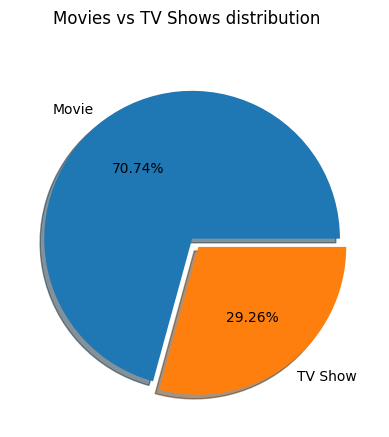

In [ ]:
plt.pie(df["type"].value_counts(),labels=df["type"].value_counts().index,
        autopct="%1.2f%%",explode=[0.03,0.04],shadow=True)
plt.suptitle('Movies vs TV Shows distribution')
plt.show()

In [ ]:
df_temp=df_new.drop_duplicates(subset=['country','title'])
df_temp

,type,title,date_added,release_year,rating,duration,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,25,9,2021,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,International TV Shows
58,TV Show,Ganglands,2021-09-24,2021,Adults,1,24,9,2021,September,Friday,Unknown,Julien Leclercq,Sami Bouajila,Crime TV Shows
85,TV Show,Kota Factory,2021-09-24,2021,Adults,2,24,9,2021,September,Friday,India,Unknown,Mayur More,International TV Shows
109,TV Show,Midnight Mass,2021-09-24,2021,Adults,1,24,9,2021,September,Friday,Unknown,Mike Flanagan,Kate Siegel,TV Dramas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198300,Movie,Zinzana,2016-03-09,2015,Adults,96,9,3,2016,March,Wednesday,Jordan,Majid Al Ansari,Ali Suliman,Dramas
198318,Movie,Zodiac,2019-11-20,2007,Adults,158,20,11,2019,November,Wednesday,United States,David Fincher,Mark Ruffalo,Cult Movies
198348,Movie,Zombieland,2019-11-01,2009,Adults,88,1,11,2019,November,Friday,United States,Ruben Fleischer,Jesse Eisenberg,Comedies
198362,Movie,Zoom,2020-01-11,2006,Kids,88,11,1,2020,January,Saturday,United States,Peter Hewitt,Tim Allen,Children & Family Movies


In [ ]:
x=df_temp['country'].value_counts().head(10)
x

,count
country,
United States,3596
India,1038
United Kingdom,772
Unknown,730
Canada,427
France,383
Japan,313
Spain,228
Germany,223


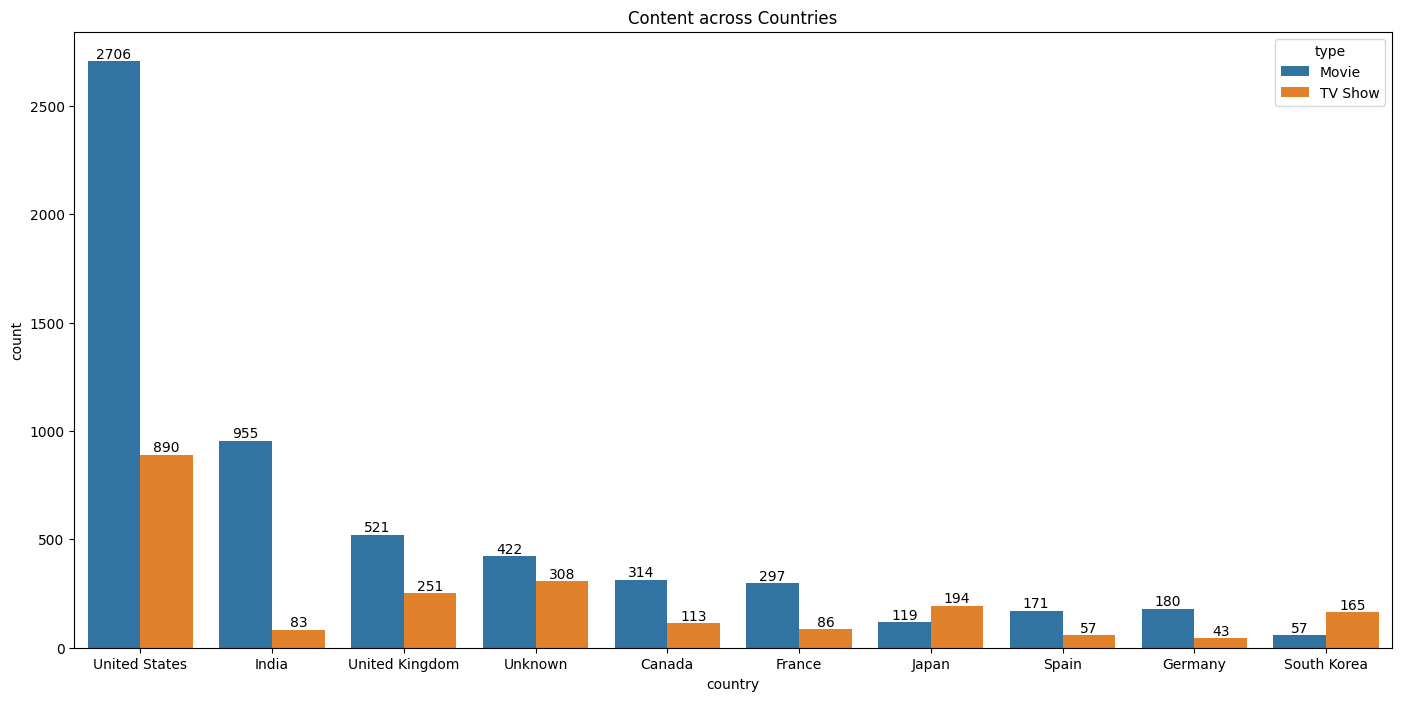

In [ ]:
plt.figure(figsize=(17,8))
plt.title('Content across Countries')
label=sns.countplot(data=df_temp,x='country',hue='type',order=x.index)
for i in label.containers:
  label.bar_label(i)
plt.show()

In [ ]:
df_movies_temp=df_movies.drop_duplicates(subset=['director','title'])
df_tvs_temp=df_tvs.drop_duplicates(subset=['director','title'])

/tmp/ipykernel_525/2770682267.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='director',order=x.index,palette='husl')
/tmp/ipykernel_525/2770682267.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='director',order=y.index,palette='husl')


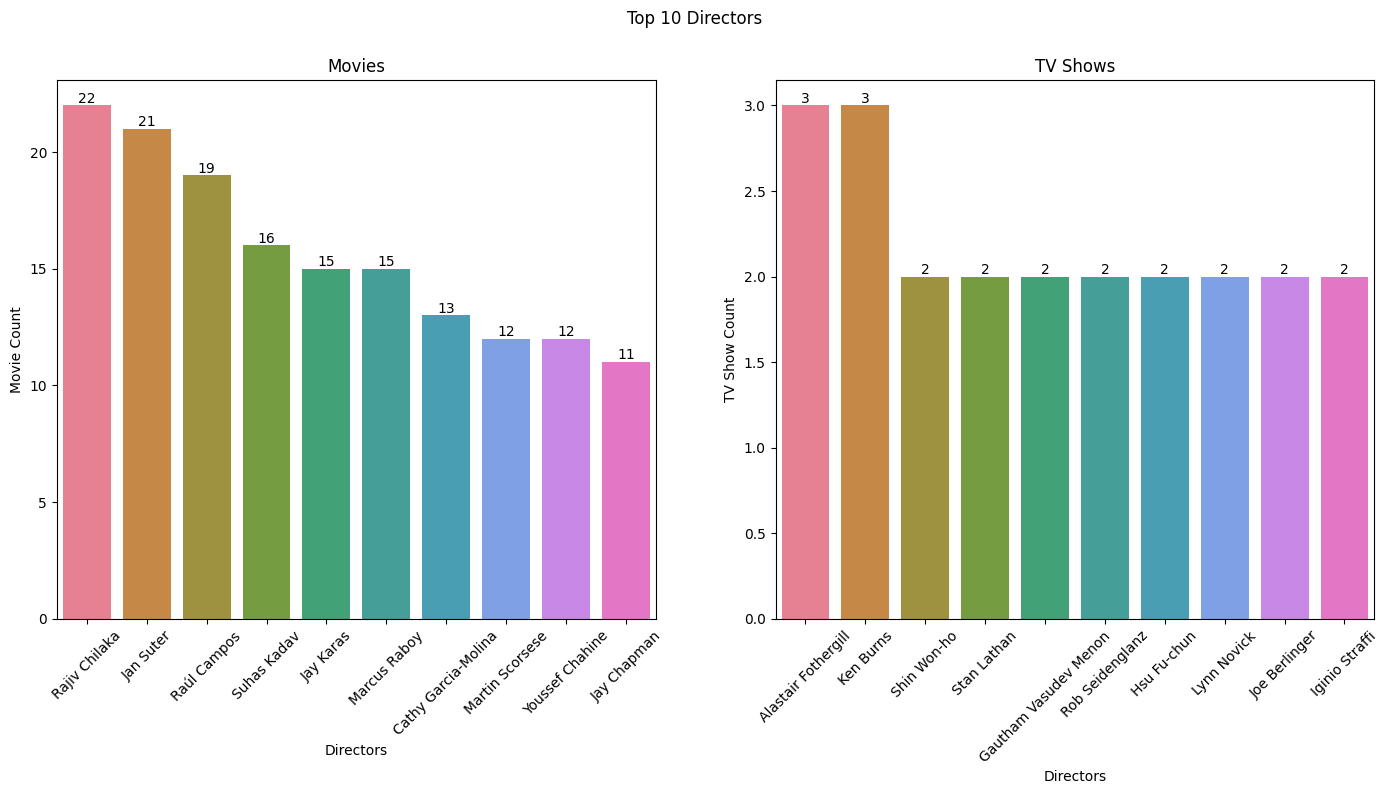

In [ ]:
plt.figure(figsize=(17,7))
plt.suptitle('Top 10 Directors')

plt.subplot(1,2,1)
x=df_movies_temp['director'].value_counts()[1:11]
label=sns.countplot(data=df_movies_temp,x='director',order=x.index,palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.title("Movies")
plt.xticks(rotation=45)
plt.xlabel("Directors")
plt.ylabel("Movie Count")

plt.subplot(1,2,2)
y=df_tvs_temp['director'].value_counts()[1:11]
label=sns.countplot(data=df_tvs_temp,x='director',order=y.index,palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.title("TV Shows")
plt.xticks(rotation=45)
plt.xlabel("Directors")
plt.ylabel("TV Show Count")
plt.show()

In [ ]:
df_movies_temp=df_movies.drop_duplicates(subset=['genre','title'])
df_tvs_temp=df_tvs.drop_duplicates(subset=['genre','title'])

/tmp/ipykernel_525/658911328.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='genre',order=x.index,palette='husl')
/tmp/ipykernel_525/658911328.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='genre',order=y.index,palette='viridis')


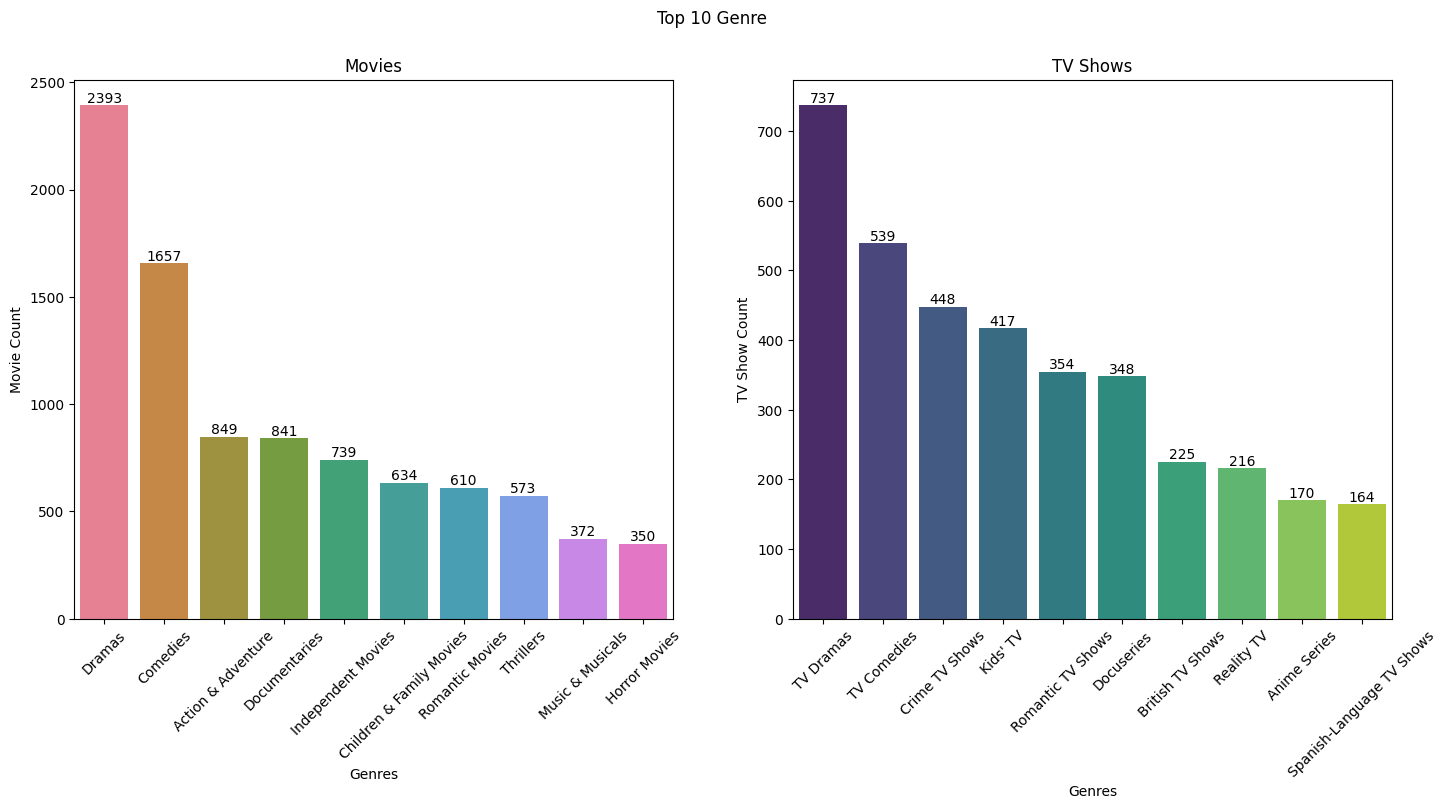

In [ ]:
plt.figure(figsize=(17,7))
plt.suptitle('Top 10 Genre')

plt.subplot(1,2,1)
x=df_movies_temp['genre'].value_counts()[1:11]
label=sns.countplot(data=df_movies_temp,x='genre',order=x.index,palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.title("Movies")
plt.xticks(rotation=45)
plt.xlabel("Genres")
plt.ylabel("Movie Count")

plt.subplot(1,2,2)
y=df_tvs_temp['genre'].value_counts()[1:11]
label=sns.countplot(data=df_tvs_temp,x='genre',order=y.index,palette='viridis')
for i in label.containers:
  label.bar_label(i)
plt.title("TV Shows")
plt.xticks(rotation=45)
plt.xlabel("Genres")
plt.ylabel("TV Show Count")
plt.show()

In [ ]:
df_movies_temp=df_movies.drop_duplicates(subset=['rating','title'])
df_tvs_temp=df_tvs.drop_duplicates(subset=['rating','title'])

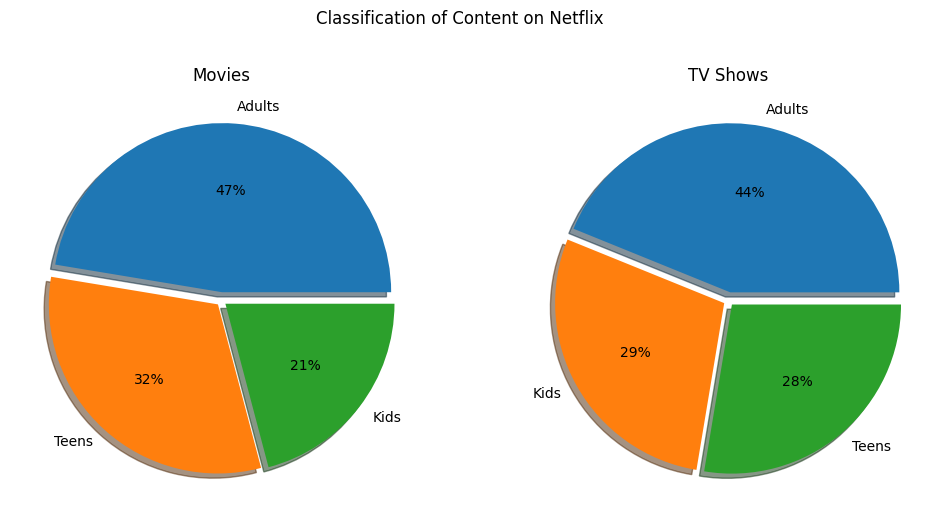

In [ ]:
plt.figure(figsize=(12,6))
plt.suptitle('Classification of Content on Netflix')

plt.subplot(1,2,1)
plt.pie(df_movies_temp['rating'].value_counts(),
        labels=df_movies_temp['rating'].value_counts().index,
        autopct='%0.0f%%',explode=(0.05,0.03,0.03),shadow=True)
plt.title("Movies")

plt.subplot(1,2,2)
plt.pie(df_tvs_temp['rating'].value_counts(),
        labels=df_tvs_temp['rating'].value_counts().index,
        autopct='%0.0f%%',explode=(0.05,0.03,0.03),shadow=True)
plt.title('TV Shows')
plt.show()

In [ ]:
df_tvs.rename(columns={'duration':'seasons'},inplace=True)

/tmp/ipykernel_525/3221938497.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs.rename(columns={'duration':'seasons'},inplace=True)


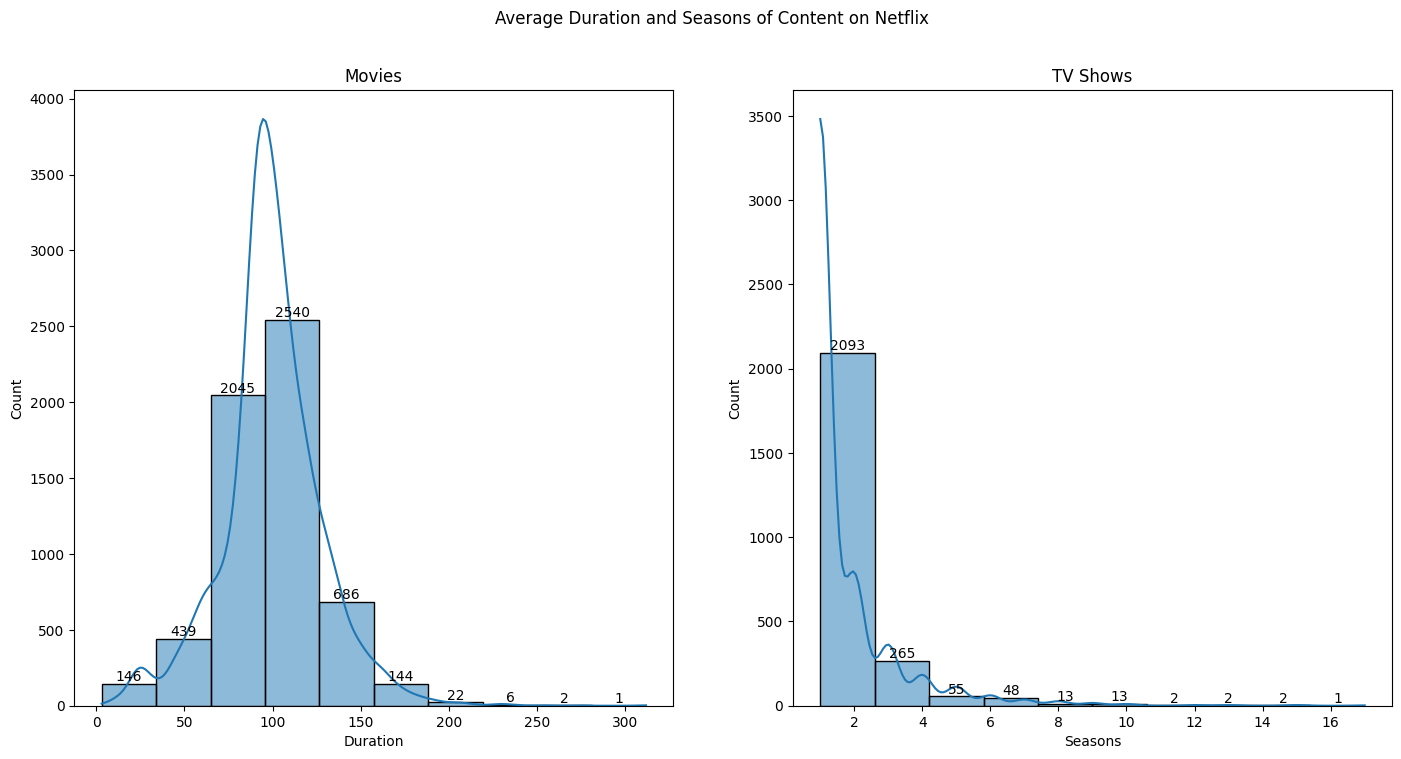

In [ ]:
df_movies_temp=df_movies.drop_duplicates(subset=['duration','title'])
df_tvs_temp=df_tvs.drop_duplicates(subset=['seasons','title'])

plt.figure(figsize=(17,8))
plt.suptitle('Average Duration and Seasons of Content on Netflix')

plt.subplot(1,2,1)
label=sns.histplot(df_movies_temp['duration'],bins=10,kde=True)
for i in label.containers:
  label.bar_label(i)
plt.xlabel('Duration')
plt.title('Movies')

plt.subplot(1,2,2)
label=sns.histplot(df_tvs_temp['seasons'],bins=10,kde=True)
for i in label.containers:
  label.bar_label(i)
plt.xlabel('Seasons')
plt.title('TV Shows')
plt.show()

In [ ]:
df_movies_temp=df_movies.drop_duplicates(subset=['year','title'])
df_movies_temp


,type,title,date_added,release_year,rating,duration,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,25,9,2021,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
157,Movie,My Little Pony: A New Generation,2021-09-24,2021,Kids,91,24,9,2021,September,Friday,Unknown,Robert Cullen,Vanessa Hudgens,Children & Family Movies
177,Movie,Sankofa,2021-09-24,1993,Adults,125,24,9,2021,September,Friday,United States,Haile Gerima,Kofi Ghanaba,Dramas
329,Movie,The Starling,2021-09-24,2021,Teens,104,24,9,2021,September,Friday,United States,Theodore Melfi,Melissa McCarthy,Comedies
426,Movie,Je Suis Karl,2021-09-23,2021,Adults,127,23,9,2021,September,Thursday,Germany,Christian Schwochow,Luna Wedler,Dramas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198282,Movie,Zinzana,2016-03-09,2015,Adults,96,9,3,2016,March,Wednesday,United Arab Emirates,Majid Al Ansari,Ali Suliman,Dramas
198318,Movie,Zodiac,2019-11-20,2007,Adults,158,20,11,2019,November,Wednesday,United States,David Fincher,Mark Ruffalo,Cult Movies
198348,Movie,Zombieland,2019-11-01,2009,Adults,88,1,11,2019,November,Friday,United States,Ruben Fleischer,Jesse Eisenberg,Comedies
198362,Movie,Zoom,2020-01-11,2006,Kids,88,11,1,2020,January,Saturday,United States,Peter Hewitt,Tim Allen,Children & Family Movies


In [ ]:
mv_year=df_movies_temp['year'].value_counts()
mv_year.sort_index(inplace=True)
mv_year

,count
year,
2008,1
2009,2
2011,13
2012,3
2013,3
2014,19
2015,51
2016,224
2017,813


In [ ]:
month_order=['January','February','March','April','May','June','July','August','September',
             'October','November','December']
mv_month=df_movies_temp['month_name'].value_counts().loc[month_order]
mv_month

,count
month_name,
January,535
February,375
March,518
April,542
May,433
June,485
July,559
August,515
September,510


In [ ]:
day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mv_day=df_movies_temp['weekday'].value_counts().loc[day_order]
mv_day

,count
weekday,
Monday,612
Tuesday,842
Wednesday,895
Thursday,1040
Friday,1537
Saturday,543
Sunday,562


/tmp/ipykernel_525/2467534846.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='year',order=mv_year.index,palette='viridis')
/tmp/ipykernel_525/2467534846.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='month_name',order=mv_month.index,palette='husl')
/tmp/ipykernel_525/2467534846.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='weekday',order=mv_day.index,palette='husl')


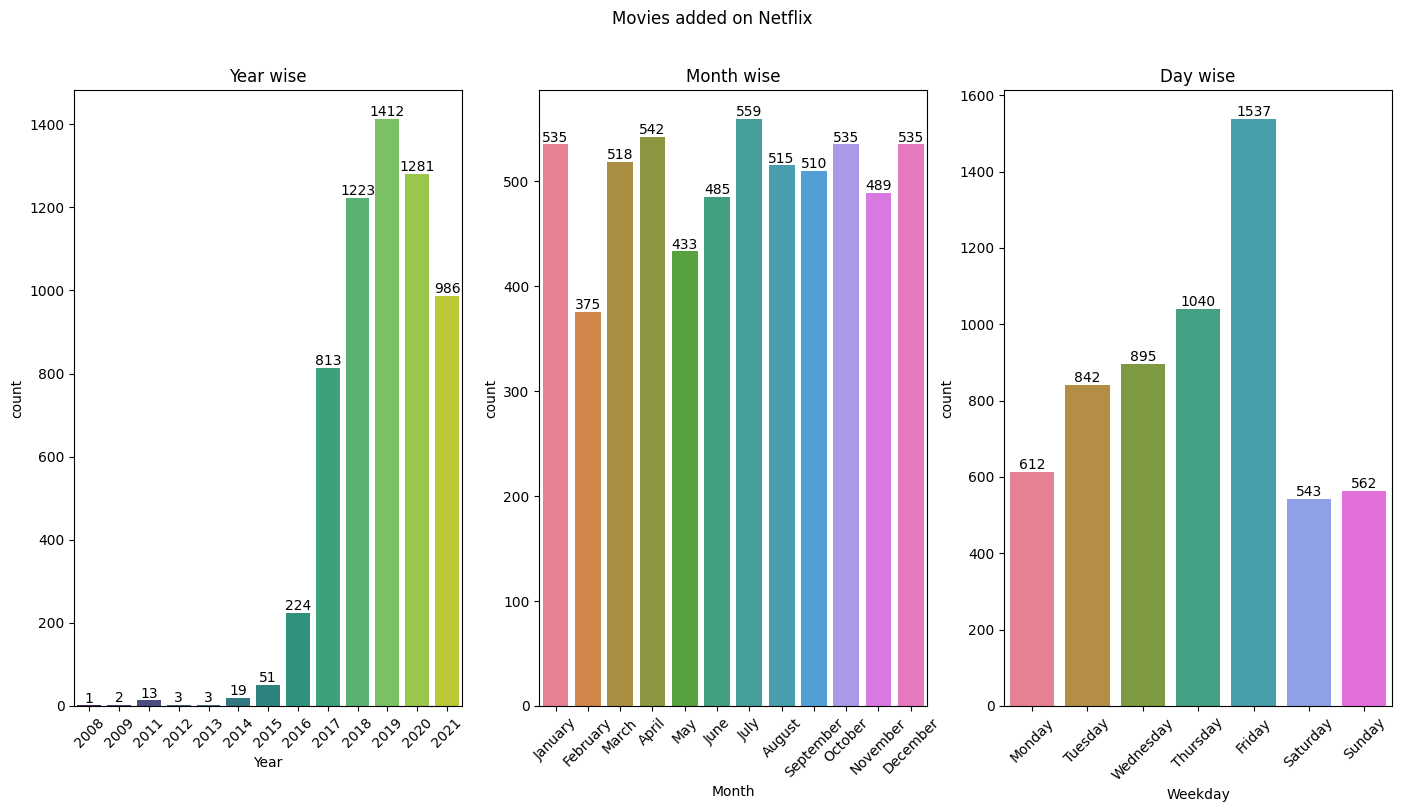

In [ ]:
plt.figure(figsize=(17,8))
plt.suptitle('Movies added on Netflix')

plt.subplot(1,3,1)
label=sns.countplot(data=df_movies_temp,x='year',order=mv_year.index,palette='viridis')
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.title('Year wise')

plt.subplot(1,3,2)
label=sns.countplot(data=df_movies_temp,x='month_name',order=mv_month.index,palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.title('Month wise')

plt.subplot(1,3,3)
label=sns.countplot(data=df_movies_temp,x='weekday',order=mv_day.index,palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Weekday')
plt.title('Day wise')
plt.show()

In [ ]:
df_tvs_temp=df_tvs.drop_duplicates(subset=['year','title'])
df_tvs_temp


,type,title,date_added,release_year,rating,seasons,day,month,year,month_name,weekday,country,director,cast,genre
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,International TV Shows
58,TV Show,Ganglands,2021-09-24,2021,Adults,1,24,9,2021,September,Friday,Unknown,Julien Leclercq,Sami Bouajila,Crime TV Shows
85,TV Show,Kota Factory,2021-09-24,2021,Adults,2,24,9,2021,September,Friday,India,Unknown,Mayur More,International TV Shows
109,TV Show,Midnight Mass,2021-09-24,2021,Adults,1,24,9,2021,September,Friday,Unknown,Mike Flanagan,Kate Siegel,TV Dramas
321,TV Show,The Great British Baking Show,2021-09-24,2021,Teens,9,24,9,2021,September,Friday,United Kingdom,Andy Devonshire,Mel Giedroyc,British TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197867,TV Show,YOM,2018-06-07,2016,Kids,1,7,6,2018,June,Thursday,Unknown,Unknown,Sairaj,Kids' TV
198125,TV Show,Yu-Gi-Oh! Arc-V,2018-05-01,2015,Kids,2,1,5,2018,May,Tuesday,Japan,Unknown,Mike Liscio,Anime Series
198145,TV Show,Yunus Emre,2017-01-17,2016,Kids,2,17,1,2017,January,Tuesday,Turkey,Unknown,Gökhan Atalay,International TV Shows
198181,TV Show,Zak Storm,2018-09-13,2016,Kids,3,13,9,2018,September,Thursday,United States,Unknown,Michael Johnston,Kids' TV


In [ ]:
tv_year=df_tvs_temp['year'].value_counts()
tv_year.sort_index(inplace=True)
tv_year

,count
year,
2008,1
2013,3
2014,4
2015,17
2016,162
2017,322
2018,377
2019,560
2020,578


In [ ]:
month_order=['January','February','March','April','May','June','July','August','September',
             'October','November','December']
tv_month=df_tvs_temp['month_name'].value_counts().loc[month_order]
tv_month

,count
month_name,
January,178
February,171
March,198
April,201
May,178
June,226
July,242
August,221
September,232


In [ ]:
day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
tv_day=df_tvs_temp['weekday'].value_counts().loc[day_order]
tv_day

,count
weekday,
Monday,212
Tuesday,322
Wednesday,348
Thursday,327
Friday,880
Saturday,237
Sunday,168


/tmp/ipykernel_525/2712974127.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='year',order=tv_year.index,palette='viridis')
/tmp/ipykernel_525/2712974127.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='month_name',order=tv_month.index,palette='husl')
/tmp/ipykernel_525/2712974127.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='weekday',order=tv_day.index,palette='husl')


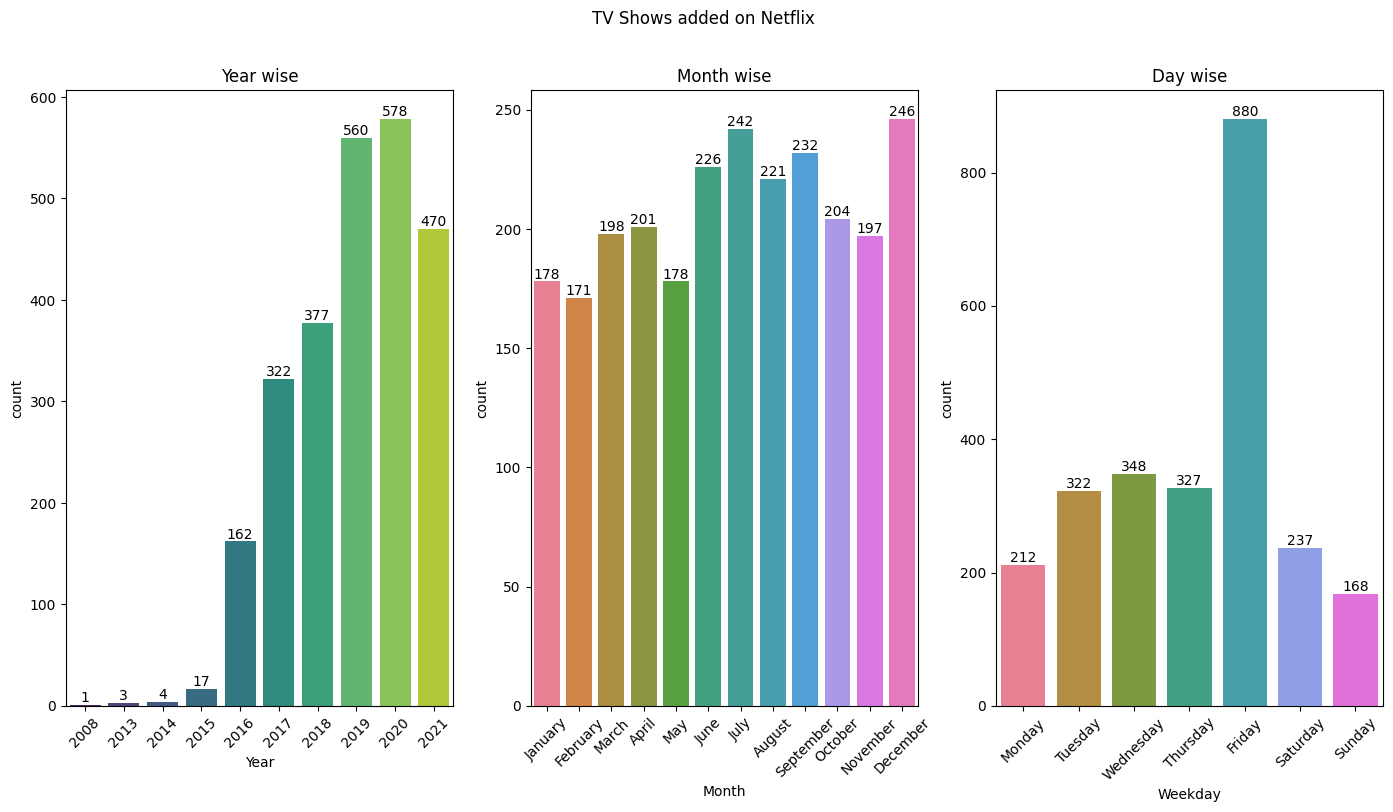

In [ ]:
plt.figure(figsize=(17,8))
plt.suptitle('TV Shows added on Netflix')

plt.subplot(1,3,1)
label=sns.countplot(data=df_tvs_temp,x='year',order=tv_year.index,palette='viridis')
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.title('Year wise')

plt.subplot(1,3,2)
label=sns.countplot(data=df_tvs_temp,x='month_name',order=tv_month.index,palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.title('Month wise')

plt.subplot(1,3,3)
label=sns.countplot(data=df_tvs_temp,x='weekday',order=tv_day.index,palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Weekday')
plt.title('Day wise')
plt.show()

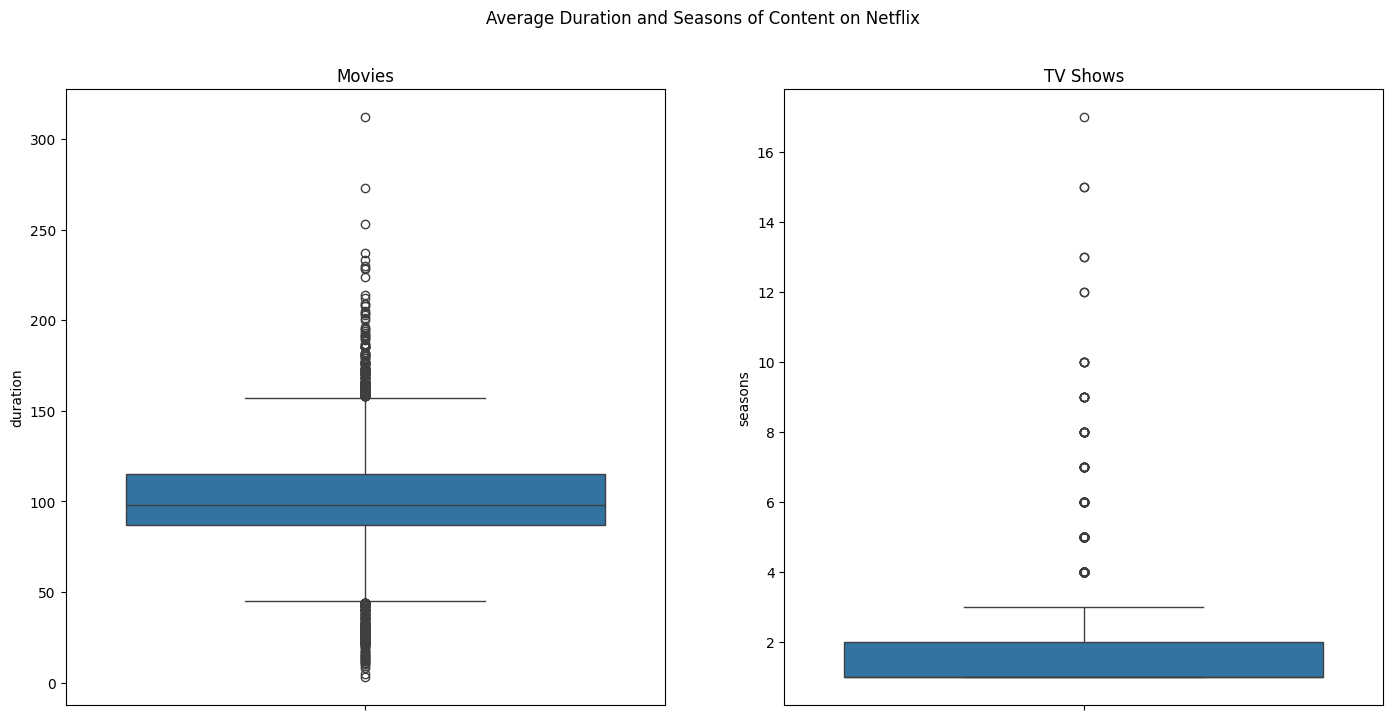

In [ ]:
plt.figure(figsize=(17,8))
plt.suptitle('Average Duration and Seasons of Content on Netflix')

plt.subplot(1,2,1)
sns.boxplot(y=df_movies_temp['duration'])
plt.title('Movies')

plt.subplot(1,2,2)
sns.boxplot(y=df_tvs_temp['seasons'])
plt.title('TV Shows')
plt.show()

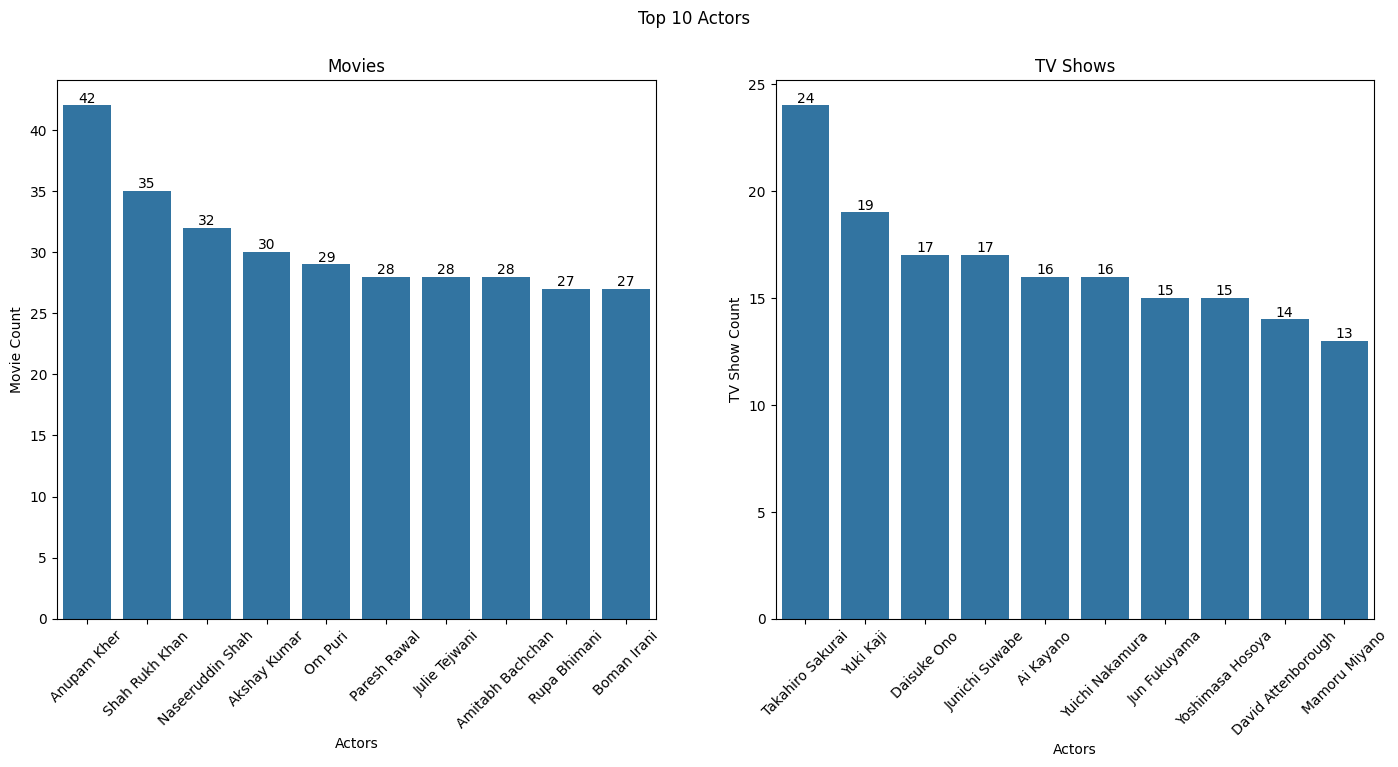

In [ ]:
df_movies_temp = df_movies.drop_duplicates(subset = ['cast','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['cast','title'])

plt.figure(figsize = (17,7))
plt.suptitle('Top 10 Actors')

plt.subplot(1,2,1)
label = sns.countplot(data=df_movies_temp, x='cast',
                      order = df_movies_temp['cast'].value_counts()[1:11].index)
for i in label.containers:
    label.bar_label(i)
plt.title("Movies")
plt.xticks(rotation=45)
plt.xlabel('Actors')
plt.ylabel('Movie Count')

plt.subplot(1,2,2)
label = sns.countplot(data=df_tvs_temp, x='cast',
                      order = df_tvs_temp['cast'].value_counts()[1:11].index)
for i in label.containers:
    label.bar_label(i)
plt.title("TV Shows")
plt.xticks(rotation=45)
plt.xlabel('Actors')
plt.ylabel('TV Show Count')

plt.show()